# FinTrust Digital Bank — Week 1

## Predictive Intelligence Problem Definition

**Track:** Data Science  
**Programme:** AnalystLab Africa Experience Lab Internship  
**Project:** FinTrust Financial Intelligence & Digital Banking Support Solution  

### Week 1 Objective

The objective of this notebook is to:
*** Understand the FinTrust customer and transaction datasets.
***Assess the suitability of `Risk_Review_Flag` as a machine-learning target. 
***Identify potential predictive features. 
***Formulate hypotheses. 
***Document data-quality observations.
***Develop an initial modelling plan.

In [19]:
import pandas as pd
import numpy as np

print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)


Pandas version: 3.0.5
NumPy version: 2.5.3


In [22]:
customer_data = pd.read_csv("Fintrust_Data/customer_data.csv")
customer_dictionary = pd.read_csv("Fintrust_Data/customer_dictionary.csv")
transaction_data = pd.read_csv("Fintrust_Data/transaction_data.csv")

print("Customer data loaded sucessfully")
print("Customer Dictionary data loaded successfully")
print("Tansaction Data loaded sucessfully")



print("Customer data shape:", customer_data.shape)
print("Trransaction data shape:", transaction_data.shape)
print("Customer dictionary shape:", customer_dictionary.shape)


Customer data loaded sucessfully
Customer Dictionary data loaded successfully
Tansaction Data loaded sucessfully
Customer data shape: (1500, 12)
Trransaction data shape: (12000, 11)
Customer dictionary shape: (12, 7)


# Dataset Dimensions

The customer dataset contains 1500 records and 12 variables.

The transaction dataset contains 12000 records and 11 variables.

The customer dictionary dataset contains 12 records and 7 variables.

In [24]:
customer_data.head()


,Customer_ID,Customer_Name,Age,Gender,City,Customer_Segment,Account_Type,Tenure_Months,Digital_Engagement_Score,Monthly_Income_Band,Preferred_Channel,Account_Status
0,FT-C00001,Ibrahim Adeyemi,56,Male,Lagos,Premium,Savings,55,84.9,500k-999k,Mobile App,Active
1,FT-C00002,Yusuf Mohammed,46,Male,Kano,Everyday,Current,79,50.7,500k-999k,Mobile App,Active
2,FT-C00003,Emeka Adeyemi,32,Female,Port Harcourt,Everyday,Savings,43,56.1,1m+,Mobile App,Active
3,FT-C00004,David Williams,60,Female,Benin City,Premium,Premium,44,54.0,500k-999k,Mobile App,Dormant
4,FT-C00005,Blessing Adeyemi,25,Male,Kaduna,Premium,Savings,68,85.1,500k-999k,Mobile App,Active


In [26]:
transaction_data.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,1/1/2026 0:32,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,1/1/2026 0:43,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


In [28]:
customer_dictionary.head()

,Field_Name,Dataset,Data_Type,Example,Definition,Business_Use,Modelling_Use
0,Customer_ID,Customer,Text,FT-C00001,Unique synthetic customer identifier,Primary key; joins to transactions,Yes
1,Customer_Name,Customer,Text,Amina Okafor,Synthetic customer display name,Portfolio/demo identification only,No
2,Age,Customer,Integer,34,Customer age,Demographic analysis,Yes
3,Gender,Customer,Category,Female,Customer-reported gender category,Demographic analysis,Yes
4,City,Customer,Category,Lagos,Customer location,Geographic analysis,Yes


In [29]:
print(customer_data.columns.tolist())
print(transaction_data.columns.tolist())
print(customer_dictionary.columns.tolist())

customer_dictionary.info()
transaction_data.info()
customer_data.info()


['Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Customer_Segment', 'Account_Type', 'Tenure_Months', 'Digital_Engagement_Score', 'Monthly_Income_Band', 'Preferred_Channel', 'Account_Status']
['Transaction_ID', 'Customer_ID', 'Transaction_DateTime', 'Transaction_Type', 'Amount_NGN', 'Channel', 'Device_Type', 'Location', 'International_Transaction', 'Transaction_Status', 'Risk_Review_Flag']
['Field_Name', 'Dataset', 'Data_Type', 'Example', 'Definition', 'Business_Use', 'Modelling_Use']
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Field_Name     12 non-null     str  
 1   Dataset        12 non-null     str  
 2   Data_Type      12 non-null     str  
 3   Example        12 non-null     str  
 4   Definition     12 non-null     str  
 5   Business_Use   12 non-null     str  
 6   Modelling_Use  12 non-null     str  
dtypes: str(7)
memory usage: 804

# Brief explanation of the previous data types(dtypes)
int64     = integer / whole number
float64   = decimal numerical value
str       = text or categorical variable

NOTE: The transaction date type in the TTRANSACTION DATA is stored as a string. Going forward, this may need conversion. 

## 4. Data Quality Assessment
The aim of this section is to identify issues such as; missing values, duplicated entry, etc., on the customer data and tghe transaction data. 

In [30]:
customer_data.isnull().sum()

Customer_ID                 0
Customer_Name               0
Age                         0
Gender                      0
City                        0
Customer_Segment            0
Account_Type                0
Tenure_Months               0
Digital_Engagement_Score    0
Monthly_Income_Band         0
Preferred_Channel           0
Account_Status              0
dtype: int64

No missing values in the customers datasets

In [31]:
transaction_data.isnull().sum()

Transaction_ID                0
Customer_ID                   0
Transaction_DateTime          0
Transaction_Type              0
Amount_NGN                    0
Channel                       0
Device_Type                  96
Location                     96
International_Transaction     0
Transaction_Status            0
Risk_Review_Flag              0
dtype: int64

From the output, there are 96 missing data entry for both the Device_type and Location colomn in the customers  transaction datasets. 

## percentage of then missing data in the dataset. 

In [32]:
customer_missing = customer_data.isnull().sum()
customer_missing_percentage = customer_missing / len(customer_data) * 100

pd.DataFrame({
    "Missing Values": customer_missing,
    "Missing Percentage": customer_missing_percentage
})

,Missing Values,Missing Percentage
Customer_ID,0,0.0
Customer_Name,0,0.0
Age,0,0.0
Gender,0,0.0
City,0,0.0
Customer_Segment,0,0.0
Account_Type,0,0.0
Tenure_Months,0,0.0
Digital_Engagement_Score,0,0.0
Monthly_Income_Band,0,0.0


In [33]:
transaction_missing = transaction_data.isnull().sum()
transaction_missing_percentage = transaction_missing / len(transaction_data) * 100

pd. DataFrame (
    {
        "Missing values": transaction_missing,
        "Missing Percentage": transaction_missing_percentage
    }
)

,Missing values,Missing Percentage
Transaction_ID,0,0.0
Customer_ID,0,0.0
Transaction_DateTime,0,0.0
Transaction_Type,0,0.0
Amount_NGN,0,0.0
Channel,0,0.0
Device_Type,96,0.8
Location,96,0.8
International_Transaction,0,0.0
Transaction_Status,0,0.0


In [34]:
print(
    "Duplicate customer rows:",
    customer_data.duplicated().sum()
)

print(
    "Duplicate transaction rows:",
    transaction_data.duplicated().sum()
)

Duplicate customer rows: 0
Duplicate transaction rows: 0


In [37]:
print(
    "Unique Customer IDs: ",  
    customer_data["Customer_ID"].nunique()
      )

print(
    "Total Customer rows: ", 
    len(customer_data)
)

print("Duplicate Customer IDs: ", 
       customer_data["Customer_ID"].duplicated().sum()
       )

Unique Customer IDs:  1500
Total Customer rows:  1500
Duplicate Customer IDs:  0


In [39]:
print("Unique Transaction ID: ", 
      transaction_data["Transaction_ID"].nunique()
      )

print(
    "Total Transaction Rows: ", 
      len(transaction_data)
      )

print(
    "Duplicate Transaction IDs: ", 
      transaction_data.duplicated().sum()
      )

Unique Transaction ID:  12000
Total Transaction Rows:  12000
Duplicate Transaction IDs:  0


## Descriptive statistics

In [40]:
customer_data.describe()

,Age,Tenure_Months,Digital_Engagement_Score
count,1500.000000,1500.000000,1500.000000
mean,41.587333,49.858667,67.954000
std,13.733127,27.910990,17.555376
min,18.000000,1.000000,16.700000
25%,29.750000,26.000000,56.100000
50%,42.000000,51.000000,68.000000
75%,53.000000,74.000000,80.925000
max,65.000000,96.000000,100.000000


In [41]:
transaction_data.describe()

,Amount_NGN
count,12000.000000
mean,46706.446238
std,86028.715234
min,100.170000
25%,2192.220000
50%,10305.935000
75%,48484.475000
max,693454.450000


In [64]:
transaction_data["Transaction_Type"].value_counts()
transaction_data["Channel"].value_counts()
transaction_data["International_Transaction"].value_counts()
transaction_data["Transaction_Status"].value_counts()

Transaction_Status
Successful    10856
Failed          630
Reversed        326
Pending         188
Name: count, dtype: int64

## 5. Target Assessment: Risk_Review_Flag


In [65]:
transaction_data["Risk_Review_Flag"].dtype


print(
    "Unique values:", transaction_data["Risk_Review_Flag"].unique())


target_count = transaction_data["Risk_Review_Flag"].value_counts()


target_percentage = transaction_data["Risk_Review_Flag"].value_counts( normalize= True) * 100


target_summary = pd.DataFrame({
    "Count": target_count,
    "Percentage": target_percentage.round(2)
})


target_summary



Unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str


,Count,Percentage
Risk_Review_Flag,,
No,9648,80.4
Yes,2352,19.6


In [66]:
unknown_customers = set(
    transaction_data["Customer_ID"]
) - set(
    customer_data["Customer_ID"]
)

print(
    "Transaction customers missing from customer dataset:",
    len(unknown_customers)
)

Transaction customers missing from customer dataset: 0


All transaction records were successfully matched to customers in the customer dataset, indicating that there are no unmatched customer IDs between the two datasets.

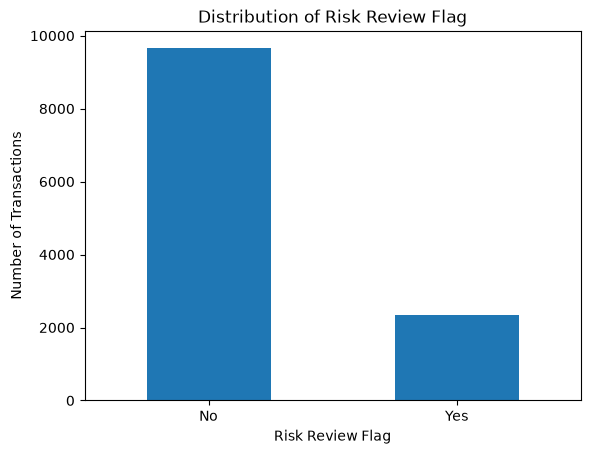

In [67]:
import matplotlib.pyplot as plt

transaction_data["Risk_Review_Flag"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Risk Review Flag")
plt.xlabel("Risk Review Flag")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)
plt.show()

### Interpretation  of the Target Distribution.

The Risk_Review_Flag is a a column or a subset of the Transaction Data. It contains two classess: 'Yes' and 'No'. 

From the chart, the target is imbalanced, with approximately 80.4 % of transaction s labelled 'No' and 19.6% labelled 'Yes'. This means that transactions not requiring risk review are much more common in the dataset. 



## 6. Predictive Problem Statement

FinTrust Digital Bank wants to determine whether historical customer and transaction information can be used to predict whether a transaction requires risk review.

The proposed machine-learning problem is therefore a supervised binary classification task in which the target variable is `Risk_Review_Flag`, with the possible outcomes `Yes` and `No`.

The purpose of the model would be to support FinTrust's risk-related decision-making by identifying transactions that may require further review. The prediction would serve as decision-support rather than as an automatic fraud determination or final banking decision.

Potential users of the prediction include FinTrust's risk, transaction-monitoring and operations teams. The output could also later be integrated into a technical workflow by the Machine Learning Engineering track.

A successful model should be able to identify a meaningful proportion of transactions requiring review while limiting unnecessary false alerts. It should also generalise to unseen data, provide interpretable outputs where possible, and be evaluated using appropriate classification metrics rather than relying only on accuracy.

## 7. Target Assessment: Risk_Review_Flag


The proposed target variable for the FinTrust predictive model is `Risk_Review_Flag`.

### Target Meaning

`Risk_Review_Flag` indicates whether a transaction in the synthetic FinTrust dataset has been labelled as requiring risk review. It should not be interpreted as a confirmed fraud indicator or as a real-world fraud determination.

### Possible Values

The variable contains two possible values:

- `Yes` — the transaction requires risk review.
- `No` — the transaction does not require risk review.

Because the target has two discrete outcome classes, the problem can be framed as a supervised binary-classification problem.

### Target Distribution

The dataset contains 12,000 transaction records.

- `No`: 9,648 transactions, representing approximately 80.4% of the dataset.
- `Yes`: 2,352 transactions, representing approximately 19.6% of the dataset.

The target is therefore imbalanced, with the `No` class occurring substantially more frequently than the `Yes` class.

### Suitability as a Modelling Target

`Risk_Review_Flag` is suitable as a potential modelling target because it represents the outcome that FinTrust wants to predict and is available for all transaction records in the dataset.

The model can therefore be trained using historical customer and transaction characteristics as predictor variables and `Risk_Review_Flag` as the target variable.

### Implications of Class Imbalance

The class imbalance means that model performance should not be assessed using accuracy alone. A model that predicts the majority class too frequently could achieve relatively high accuracy while failing to identify transactions requiring review.


### Limitations of the Target

Several limitations should be considered when using `Risk_Review_Flag`:

1. The label is synthetic and was created for educational purposes.
2. It should not be treated as a confirmed fraud label.
3. The method used to generate the label may reflect simplified or artificial patterns.
4. A model trained on this synthetic dataset may not generalise to real banking transactions.
5. Any future real-world application would require additional validation, governance, fairness assessment and domain-specific review.



## 8. Candidate Features

The following variables are potential predictors for `Risk_Review_Flag`. These are candidate features rather than final model inputs.

| Feature | Why It May Matter | Data Type | Potential Concern |
|---|---|---|---|
| `Amount_NGN` | Transaction amount may help show unusual or different spending patterns. | Numerical | Very large values may affect the model. |
| `Transaction_Type` | Different transaction types may have different risk-review patterns. | Categorical | Some transaction types may have very few records. |
| `Channel` | The way a transaction is carried out may affect transaction behaviour. | Categorical | Categories will need to be converted before modelling. |
| `Device_Type` | Different devices may be linked to different transaction behaviours. | Categorical | Some values are missing. |
| `Location` | Transactions from different locations may show different patterns. | Categorical | Some values are missing and there may be many locations. |
| `International_Transaction` | International transactions may show different review patterns from local transactions. | Categorical / Binary | International transactions should not automatically be treated as risky. |
| `Transaction_Status` | Failed, successful or reversed transactions may show different review patterns. | Categorical | Could cause data leakage if the status is known only after review. |
| `Age` | Different age groups may have different transaction habits. | Numerical | May raise fairness concerns. |
| `Customer_Segment` | Different customer groups may behave differently. | Categorical | Segments may already include business assumptions. |
| `Account_Type` | Different account types may have different transaction patterns. | Categorical | Differences may come from account rules rather than actual risk. |
| `Tenure_Months` | New and long-term customers may show different behaviours. | Numerical | A relationship does not mean it causes risk. |
| `Digital_Engagement_Score` | Customer activity on digital banking may relate to transaction behaviour. | Numerical | We need to understand how the score was created. |


## 9. Initial Hypotheses

The following hypotheses will be tested during later exploratory analysis and modelling. They are not conclusions at this stage.

### Hypothesis 1
Transactions with higher amounts may be more likely to receive a `Risk_Review_Flag = Yes` than lower-value transactions.

### Hypothesis 2
International transactions may have a different risk-review pattern compared with local transactions.

### Hypothesis 3
The risk-review rate may differ across transaction types.

### Hypothesis 4
The risk-review rate may differ across transaction channels.

### Hypothesis 5
Customer characteristics such as account type, customer segment, tenure, and digital engagement may be associated with whether a transaction is flagged for risk review.

## 10. Initial Modelling Plan

The modelling process will be carried out in stages to ensure that the data is properly prepared, the model is evaluated fairly, and the final results are understandable.

### 1. Data Preparation

The customer and transaction datasets will first be linked using `Customer_ID`.

The following preparation steps will then be considered:

- Convert `Transaction_DateTime` into a proper datetime format.
- Investigate and handle missing values in `Device_Type` and `Location`.
- Check numerical variables for unusual or extreme values.
- Convert categorical variables into a format suitable for machine learning.
- Separate the predictor variables from the target variable, `Risk_Review_Flag`.
- Review candidate features for possible target leakage before modelling.

### 2. Exploratory Data Analysis

Further analysis will be carried out to understand how different variables relate to `Risk_Review_Flag`.

Areas to investigate include:

- Transaction amount and risk-review outcome.
- Risk-review rates across transaction types.
- Risk-review rates across transaction channels.
- International versus local transactions.
- Transaction status and risk-review outcome.
- Customer segments and account types.
- Customer tenure and digital engagement.
- Patterns based on transaction date and time.

These analyses will help determine which variables may be useful predictors.

### 3. Feature Engineering

Additional features may be created from the existing data where appropriate.

Possible examples include:

- Transaction hour.
- Day of the week.
- Weekend indicator.
- Number of transactions made by each customer.
- Average transaction amount per customer.
- Transaction amount compared with the customer's normal transaction amount.

Feature engineering will only be performed when the available data supports it.

### 4. Baseline Model

Logistic Regression will be considered as the initial baseline model.

It provides a simple and interpretable starting point that can be used to compare the performance of more complex models.

### 5. Candidate Algorithms

After establishing the baseline, other classification algorithms may be tested, including:

- Decision Tree
- Random Forest
- Gradient Boosting

The aim will not be to select the most complex model, but to identify a model that provides a good balance between predictive performance and interpretability.

### 6. Evaluation Metrics

Because `Risk_Review_Flag` is imbalanced, model performance will not be assessed using accuracy alone.

The following metrics will be considered:

- Precision
- Recall
- F1-score
- Confusion Matrix
- ROC-AUC
- PR-AUC

Recall will help measure how many transactions requiring review are correctly identified, while precision will help measure how many predicted review cases are actually labelled for review.

### 7. Validation

The dataset will be divided into training and testing sets so that model performance can be evaluated on data that was not used during training.

A stratified split will be considered so that the proportion of `Yes` and `No` cases is maintained in both the training and testing datasets.

Cross-validation may also be considered during model development to obtain a more reliable estimate of model performance.

### 8. Error Analysis

Model errors will be examined after prediction.

Particular attention will be given to:

- False positives: transactions predicted as requiring review when they are labelled `No`.
- False negatives: transactions predicted as not requiring review when they are labelled `Yes`.

This will help determine where the model performs poorly and whether improvements are required.

### 9. Model Limitations

Several limitations will be considered when interpreting the model:

- The FinTrust data is synthetic and intended for educational purposes.
- `Risk_Review_Flag` is not a confirmed fraud label.
- The model may learn artificial patterns created during synthetic-data generation.
- Results may not generalise to real banking transactions.
- Some variables may create fairness or bias concerns.
- Model predictions should support human decision-making rather than replace it.

## 11. Data-Quality Observations

The initial review of the FinTrust datasets produced the following observations:

1. The customer dataset contains 1,500 records and 12 columns, while the transaction dataset contains 12,000 records and 11 columns.

2. No missing values were identified in the customer dataset.

3. The transaction dataset contains missing values in two variables:
   - `Device_Type`: 96 missing values.
   - `Location`: 96 missing values.

4. `Risk_Review_Flag`, which is the proposed modelling target, contains no missing values.

5. No duplicate rows were identified in either the customer or transaction dataset.

6. `Customer_ID` is unique within the customer dataset, and `Transaction_ID` is unique within the transaction dataset.

7. All customer IDs appearing in the transaction dataset were successfully matched to customers in the customer dataset. This means there are no transaction records linked to unknown customers.

8. The customer and transaction datasets therefore have a one-to-many relationship, where one customer can have multiple transactions.

9. `Risk_Review_Flag` contains two values: `Yes` and `No`. The distribution is imbalanced, with 9,648 `No` records (80.4%) and 2,352 `Yes` records (19.6%).

10. Some categorical variables will require further preparation before modelling, while `Transaction_DateTime` will need to be converted into a proper datetime format before date-based features can be created.

11. The wide range of values observed in `Amount_NGN` suggests that transaction amounts should be examined further for skewness and possible extreme values during exploratory analysis.

Overall, the datasets appear suitable for further modelling work, but missing values, class imbalance, categorical variables, date conversion and possible extreme transaction amounts will need to be addressed during the data-preparation stage.

## 12. Data Science Objectives

The main objectives of the Data Science contribution to the FinTrust project are to:

1. Assess whether `Risk_Review_Flag` is suitable as a machine-learning target.

2. Understand the structure, quality, and relationship of the customer and transaction datasets.

3. Identify customer and transaction features that may help predict whether a transaction requires risk review.

4. Develop testable hypotheses about factors that may be associated with the risk-review label.

5. Create a clear modelling and evaluation plan that can guide model development during Weeks 2–4.

## 13. Success Criteria

The Data Science solution will be considered successful if:

1. The predictive problem is clearly defined and linked to the FinTrust business problem.

2. The customer and transaction data are properly understood, prepared, and documented.

3. The model developed in later weeks performs better than a simple baseline.

4. Model performance is evaluated using suitable metrics such as precision, recall, F1-score, ROC-AUC, PR-AUC, and a confusion matrix.

5. The model can identify transactions requiring review without producing an excessive number of false alerts.

6. Important model features and predictions can be explained clearly to both technical and non-technical stakeholders.

7. Limitations, assumptions, and risks are clearly documented.

8. The final work is reproducible, professionally presented, and suitable for inclusion in a portfolio.

## 14. Risks and Limitations

| Risk | Possible Impact | Planned Response |
|---|---|---|
| Missing values | May reduce data quality or affect some model features. | Investigate missing values and choose an appropriate treatment during data preparation. |
| Class imbalance | The model may favour the majority `No` class. | Use suitable evaluation metrics and stratified validation. |
| Target leakage | Some variables may reveal information that is only available after the review decision. | Check when each feature becomes available before including it in the model. |
| Synthetic data | Model results may not represent real banking behaviour. | Clearly document that the dataset is educational and synthetic. |
| Overfitting | The model may perform well on training data but poorly on unseen data. | Use train/test validation and consider cross-validation. |
| Extreme transaction values | Very large transaction amounts may influence the model strongly. | Investigate the amount distribution during exploratory analysis. |
| Fairness concerns | Some customer characteristics may lead to unfair model behaviour. | Review sensitive features carefully and assess model performance across relevant groups. |
| Limited interpretability | Complex models may be difficult to explain. | Compare complex models with an interpretable baseline such as Logistic Regression. |

## 15. Future Cross-Track Dependencies

The Data Science track may depend on outputs from other tracks as the FinTrust project progresses.

| Track | Possible Dependency |
|---|---|
| Data Analytics | Business insights and transaction patterns may help guide feature selection and interpretation. |
| Machine Learning Engineering | The trained model, preprocessing requirements, and prediction outputs may later need to be integrated into a reproducible workflow or service. |
| Project Management | Coordination may be required for timelines, dependencies, integration, and final delivery. |
| Generative AI | Predictive or analytical outputs may later contribute to the wider integrated FinTrust solution where appropriate. |

These dependencies are only initial planning considerations. Formal collaboration begins from Week 2.

# 16. Week 2–4 Plan

### Week 2 — Analyse & Prepare

The focus will be on deeper exploratory analysis and preparation of the modelling dataset.

Planned activities include:

- Merge relevant customer and transaction information.
- Investigate missing values and decide how they should be handled.
- Convert date/time fields into appropriate formats.
- Explore the relationship between candidate features and `Risk_Review_Flag`.
- Investigate the Week 1 hypotheses.
- Prepare categorical and numerical variables for modelling.
- Create initial engineered features where appropriate.
- Develop an initial baseline classification model.
- Begin formal cross-track collaboration.

### Week 3 — Develop & Integrate

The focus will shift to model development, comparison, and validation.

Planned activities include:

- Train selected classification algorithms.
- Compare candidate models against the baseline.
- Evaluate model performance using appropriate classification metrics.
- Perform feature interpretation.
- Conduct validation and error analysis.
- Investigate false positives and false negatives.
- Refine the modelling approach where necessary.
- Share relevant model requirements and outputs with the Machine Learning Engineering track.

### Week 4 — Test, Refine & Present

The final week will focus on testing, refinement, documentation, and presentation.

Planned activities include:

- Complete final model evaluation.
- Review errors and limitations.
- Refine the model where improvements are justified.
- Document the final modelling workflow.
- Support integration with the wider FinTrust solution.
- Prepare the final project report.
- Prepare the individual recorded presentation.

# 16. Week 2–4 Plan

### Week 2 — Analyse & Prepare

The focus will be on deeper exploratory analysis and preparation of the modelling dataset.

Planned activities include:

- Merge relevant customer and transaction information.
- Investigate missing values and decide how they should be handled.
- Convert date/time fields into appropriate formats.
- Explore the relationship between candidate features and `Risk_Review_Flag`.
- Investigate the Week 1 hypotheses.
- Prepare categorical and numerical variables for modelling.
- Create initial engineered features where appropriate.
- Develop an initial baseline classification model.
- Begin formal cross-track collaboration.

### Week 3 — Develop & Integrate

The focus will shift to model development, comparison, and validation.

Planned activities include:

- Train selected classification algorithms.
- Compare candidate models against the baseline.
- Evaluate model performance using appropriate classification metrics.
- Perform feature interpretation.
- Conduct validation and error analysis.
- Investigate false positives and false negatives.
- Refine the modelling approach where necessary.
- Share relevant model requirements and outputs with the Machine Learning Engineering track.

### Week 4 — Test, Refine & Present

The final week will focus on testing, refinement, documentation, and presentation.

Planned activities include:

- Complete final model evaluation.
- Review errors and limitations.
- Refine the model where improvements are justified.
- Document the final modelling workflow.
- Support integration with the wider FinTrust solution.
- Prepare the final project report.
- Prepare the individual recorded presentation.

## General Week 1 Requirement.

## 12. Data Science Objectives

The main objectives of the Data Science contribution to the FinTrust project are to:

1. Assess whether `Risk_Review_Flag` is suitable as a machine-learning target.

2. Understand the structure, quality, and relationship of the customer and transaction datasets.

3. Identify customer and transaction features that may help predict whether a transaction requires risk review.

4. Develop testable hypotheses about factors that may be associated with the risk-review label.

5. Create a clear modelling and evaluation plan that can guide model development during Weeks 2–4.

## 13. Success Criteria

The Data Science solution will be considered successful if:

1. The predictive problem is clearly defined and linked to the FinTrust business problem.

2. The customer and transaction data are properly understood, prepared, and documented.

3. The model developed in later weeks performs better than a simple baseline.

4. Model performance is evaluated using suitable metrics such as precision, recall, F1-score, ROC-AUC, PR-AUC, and a confusion matrix.

5. The model can identify transactions requiring review without producing an excessive number of false alerts.

6. Important model features and predictions can be explained clearly to both technical and non-technical stakeholders.

7. Limitations, assumptions, and risks are clearly documented.

8. The final work is reproducible, professionally presented, and suitable for inclusion in a portfolio.

## 14. Risks and Limitations

| Risk | Possible Impact | Planned Response |
|---|---|---|
| Missing values | May reduce data quality or affect some model features. | Investigate missing values and choose an appropriate treatment during data preparation. |
| Class imbalance | The model may favour the majority `No` class. | Use suitable evaluation metrics and stratified validation. |
| Target leakage | Some variables may reveal information that is only available after the review decision. | Check when each feature becomes available before including it in the model. |
| Synthetic data | Model results may not represent real banking behaviour. | Clearly document that the dataset is educational and synthetic. |
| Overfitting | The model may perform well on training data but poorly on unseen data. | Use train/test validation and consider cross-validation. |
| Extreme transaction values | Very large transaction amounts may influence the model strongly. | Investigate the amount distribution during exploratory analysis. |
| Fairness concerns | Some customer characteristics may lead to unfair model behaviour. | Review sensitive features carefully and assess model performance across relevant groups. |
| Limited interpretability | Complex models may be difficult to explain. | Compare complex models with an interpretable baseline such as Logistic Regression. |

## 15. Future Cross-Track Dependencies

The Data Science track may depend on outputs from other tracks as the FinTrust project progresses.

| Track | Possible Dependency |
|---|---|
| Data Analytics | Business insights and transaction patterns may help guide feature selection and interpretation. |
| Machine Learning Engineering | The trained model, preprocessing requirements, and prediction outputs may later need to be integrated into a reproducible workflow or service. |
| Project Management | Coordination may be required for timelines, dependencies, integration, and final delivery. |
| Generative AI | Predictive or analytical outputs may later contribute to the wider integrated FinTrust solution where appropriate. |

These dependencies are only initial planning considerations. Formal collaboration begins from Week 2.

## 16. Week 2–4 Plan

### Week 2 — Analyse & Prepare

The focus will be on deeper exploratory analysis and preparation of the modelling dataset.

Planned activities include:

- Merge relevant customer and transaction information.
- Investigate missing values and decide how they should be handled.
- Convert date/time fields into appropriate formats.
- Explore the relationship between candidate features and `Risk_Review_Flag`.
- Investigate the Week 1 hypotheses.
- Prepare categorical and numerical variables for modelling.
- Create initial engineered features where appropriate.
- Develop an initial baseline classification model.
- Begin formal cross-track collaboration.


### Week 3 — Develop & Integrate

The focus will shift to model development, comparison, and validation.

Planned activities include:

- Train selected classification algorithms.
- Compare candidate models against the baseline.
- Evaluate model performance using appropriate classification metrics.
- Perform feature interpretation.
- Conduct validation and error analysis.
- Investigate false positives and false negatives.
- Refine the modelling approach where necessary.
- Share relevant model requirements and outputs with the Machine Learning Engineering track.


### Week 4 — Test, Refine & Present

The final week will focus on testing, refinement, documentation, and presentation.

Planned activities include:

- Complete final model evaluation.
- Review errors and limitations.
- Refine the model where improvements are justified.
- Document the final modelling workflow.
- Support integration with the wider FinTrust solution.
- Prepare the final project report.
- Prepare the individual recorded presentation.